# Distortion Correction Pipeline



## Load Libraries

In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Visualize Test Image

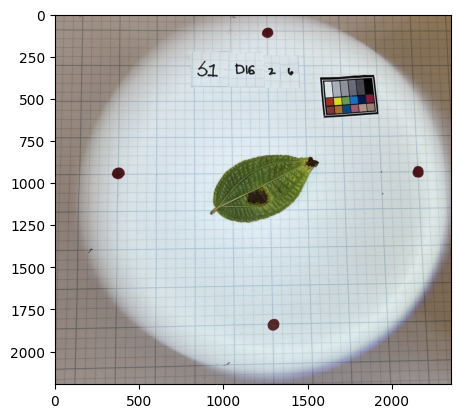

In [14]:
im = cv2.imread("../../img/test/Rusted_Ventral.JPG").astype(float)
im = im[:, :, ::-1]

plt.imshow(im.astype(np.uint8))
plt.show()

## Create a Redness Grayscale Map  

### Create a measure of redness

In [16]:
redness = im[:,:,0] / (im[:,:,1] + im[:,:,2] + 1)

In [17]:
print(np.max(redness), np.min(redness), np.median(redness))

41.0 0.0 0.47580645161290325


### Create a redness matrix

In [18]:
red_clip = 2
redness[redness>red_clip] = red_clip

### Display the redness map

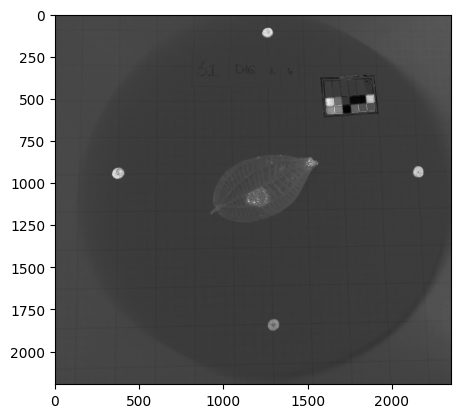

In [19]:
r_display = redness / red_clip * 255

plt.gray()
plt.imshow(r_display.astype(np.uint8))
plt.show()

## Identify the Redness Threshold

### Display the Redness Histogram for the Test Image



(array([4.584000e+03, 2.369000e+03, 1.236000e+03, 8.790000e+02,
        1.046000e+03, 1.220000e+03, 1.098000e+03, 1.302000e+03,
        2.285000e+03, 3.226000e+03, 1.069850e+05, 2.828362e+06,
        6.433310e+05, 6.460040e+05, 5.770430e+05, 1.361650e+05,
        1.449090e+05, 2.071800e+04, 4.916000e+03, 3.439000e+03,
        2.341000e+03, 2.357000e+03, 2.381000e+03, 1.388000e+03,
        1.275000e+03, 2.234000e+03, 1.573000e+03, 1.337000e+03,
        1.049000e+03, 8.050000e+02, 6.700000e+02, 6.170000e+02,
        6.110000e+02, 7.010000e+02, 7.080000e+02, 9.140000e+02,
        9.700000e+02, 9.280000e+02, 1.090000e+03, 8.750000e+02,
        9.200000e+02, 7.540000e+02, 7.500000e+02, 5.570000e+02,
        4.890000e+02, 5.420000e+02, 3.610000e+02, 2.560000e+02,
        2.280000e+02, 1.842000e+03]),
 array([  0. ,   5.1,  10.2,  15.3,  20.4,  25.5,  30.6,  35.7,  40.8,
         45.9,  51. ,  56.1,  61.2,  66.3,  71.4,  76.5,  81.6,  86.7,
         91.8,  96.9, 102. , 107.1, 112.2, 117.3, 12

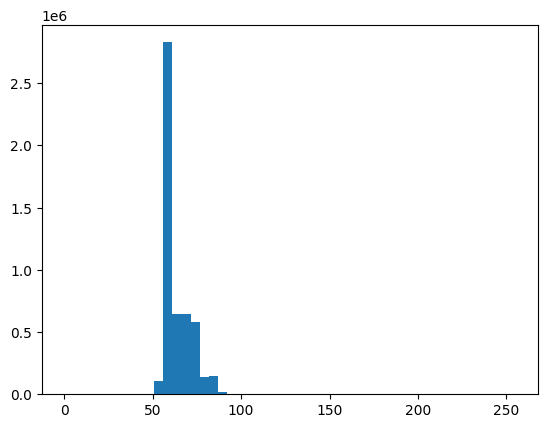

In [20]:
flat_display = r_display.flatten()
plt.hist(flat_display, bins=50)


### Assign a threshold based on the analysis of the histogram

In [21]:
thresh = 120

### Create a binary matrix

In [22]:
_, thresholded_image = cv2.threshold(r_display, 120, 255, cv2.THRESH_BINARY)


### Display the binary matrix

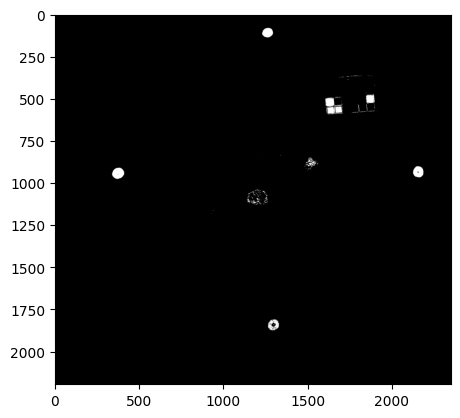

In [23]:
plt.gray()
plt.imshow(thresholded_image.astype(np.uint8))
plt.show()

## Apply morphological transformations to highlight the red dots

### Apply a Close then Open Transform

In [24]:
kernel = np.ones((5,5),np.uint8)

after_close = cv2.morphologyEx(thresholded_image,cv2.MORPH_CLOSE,kernel)
im_close_first = cv2.morphologyEx(after_close,cv2.MORPH_OPEN,kernel)


### Visualize the Transformation

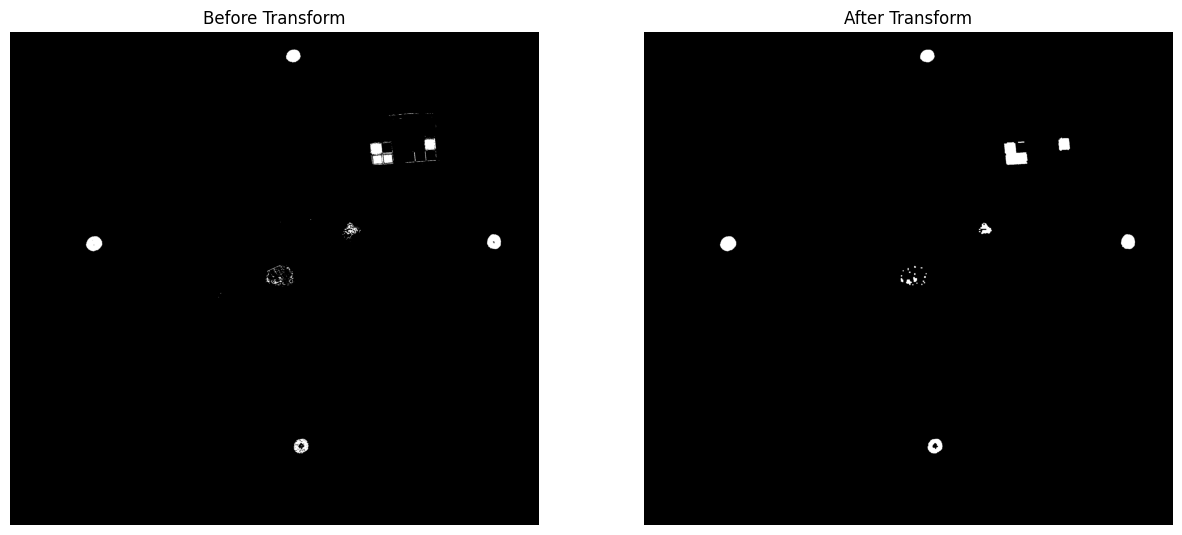

In [25]:

plt.figure(figsize=(15,15))
plt.subplot(121)
plt.axis("off")
plt.imshow(thresholded_image)
plt.title("Before Transform")
plt.subplot(122)
plt.axis("off")
plt.imshow(im_close_first)
plt.title("After Transform")
plt.show()

## Cluster the pixels through connected components

### Run Connected Components Labeling on the Morphologically Transformed Image

In [26]:
connectivity = 8
num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(im_close_first.astype(np.uint8), connectivity, cv2.CV_32S)
print('Number of connected components:', num_labels-1)  # the background is one of the "labels"
print('\nHere are the stats:')
print('Upper left and lower right pixel, plus area')
print(stats)
print('\nHere are the centroids')
print(centroids)


Number of connected components: 26

Here are the stats:
Upper left and lower right pixel, plus area
[[      0       0    2352    2195 5137271]
 [   1228      83      64      56    2832]
 [   1843     474      51      58    2478]
 [   1663     491      28       6     140]
 [   1601     494     104     101    7146]
 [   1489     852      57      50    1485]
 [   1489     889       7       5      35]
 [   2121     903      62      66    3251]
 [    338     912      72      67    3650]
 [   1201    1044       8       8      59]
 [   1230    1050       8       5      40]
 [   1172    1053       5      10      50]
 [   1150    1063       5       5      25]
 [   1178    1069       7       6      42]
 [   1201    1076       6       8      48]
 [   1252    1076       5       5      25]
 [   1142    1085       6       6      35]
 [   1245    1089       8       8      62]
 [   1197    1093      17      22     280]
 [   1141    1098      12      18     162]
 [   1165    1104      26      25     39

### Sort the clusters by size

In [27]:
sizes = stats[:, cv2.CC_STAT_AREA]

ind = np.argsort(sizes)
sizes = sizes[ind]
centroids = centroids[ind]

In [28]:
centroids

array([[1254.        , 1078.        ],
       [1195.        , 1127.        ],
       [1152.        , 1065.        ],
       [1213.        , 1120.        ],
       [1235.        , 1125.5       ],
       [1246.5       , 1118.        ],
       [1144.42857143, 1087.42857143],
       [1492.        ,  891.        ],
       [1233.5       , 1052.        ],
       [1242.125     , 1111.375     ],
       [1181.        , 1071.5       ],
       [1203.5       , 1079.5       ],
       [1174.        , 1057.5       ],
       [1204.27118644, 1047.76271186],
       [1248.61290323, 1092.59677419],
       [1676.5       ,  493.53571429],
       [1146.39506173, 1107.00617284],
       [1204.425     , 1103.87857143],
       [1176.81074169, 1115.01023018],
       [1518.59393939,  879.48821549],
       [1867.31113801,  502.32606941],
       [1259.49682203,  110.29519774],
       [1293.64867583, 1843.88568555],
       [2152.04767764,  936.17809905],
       [ 373.73369863,  944.41808219],
       [1646.45815841,  5

### Concatenate the Centroids Coordinates Matrix with the Area Array

In [29]:
sizes = sizes.reshape((sizes.shape[0], 1))
concat_array = np.concatenate((centroids, sizes), axis=1)
concat_array = concat_array[::-1]

### Filter the Clusters by Size

In [30]:
condition = concat_array[:, 2] > 1000
filtered_data = concat_array[condition]

### Extract the four red dots

In [31]:
right_point = filtered_data[np.argmax(filtered_data[:, 0])]
left_point = filtered_data[np.argmin(filtered_data[:, 0])]
lower_point = filtered_data[np.argmax(filtered_data[:, 1])]
upper_point = filtered_data[np.argmin(filtered_data[:, 1])]

point_A = [upper_point[0], upper_point[1]]  # Top point
point_B = [lower_point[0], lower_point[1]]  # Bottom point
point_C = [left_point[0], left_point[1]]  # Left point
point_D = [right_point[0], right_point[1]]  # Right point

### Visualize the red dots

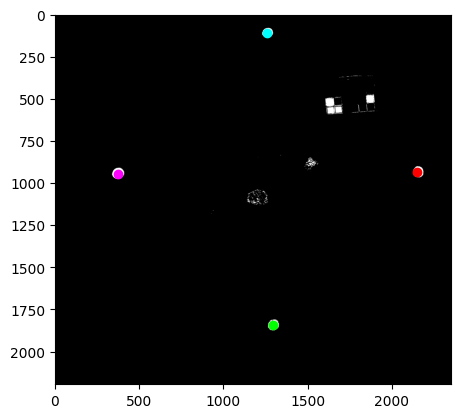

In [32]:
plt.gray()
plt.imshow(thresholded_image.astype(np.uint8))
plt.scatter(point_A[0], point_A[1], color='cyan')
plt.scatter(point_B[0], point_B[1], color='lime')
plt.scatter(point_C[0], point_C[1], color='fuchsia')
plt.scatter(point_D[0], point_D[1], color='red')
plt.show()

## Correct the Distortion in the Image

### Utility function

In [33]:
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

### Define the Input Points

In [35]:
input_points = np.array([point_A, point_B, point_C, point_D], dtype='float32')

### Define the Destination Points

In [37]:
rect_width = int(euclidean_distance(point_C, point_D))
rect_height = int(euclidean_distance(point_A, point_B))

output_points = np.array([
    [rect_width // 2, 0],           # Top middle
    [rect_width // 2, rect_height], # Bottom middle
    [0, rect_height // 2],          # Left middle
    [rect_width, rect_height // 2]  # Right middle
], dtype='float32')

### Compute the Perspective Transform Matrix

In [38]:
matrix = cv2.getPerspectiveTransform(input_points, output_points)

### Apply the Transformation to obtain the Transformed Image

In [39]:
transformed_image = cv2.warpPerspective(im, matrix, (rect_width, rect_height))


### Visualize the result

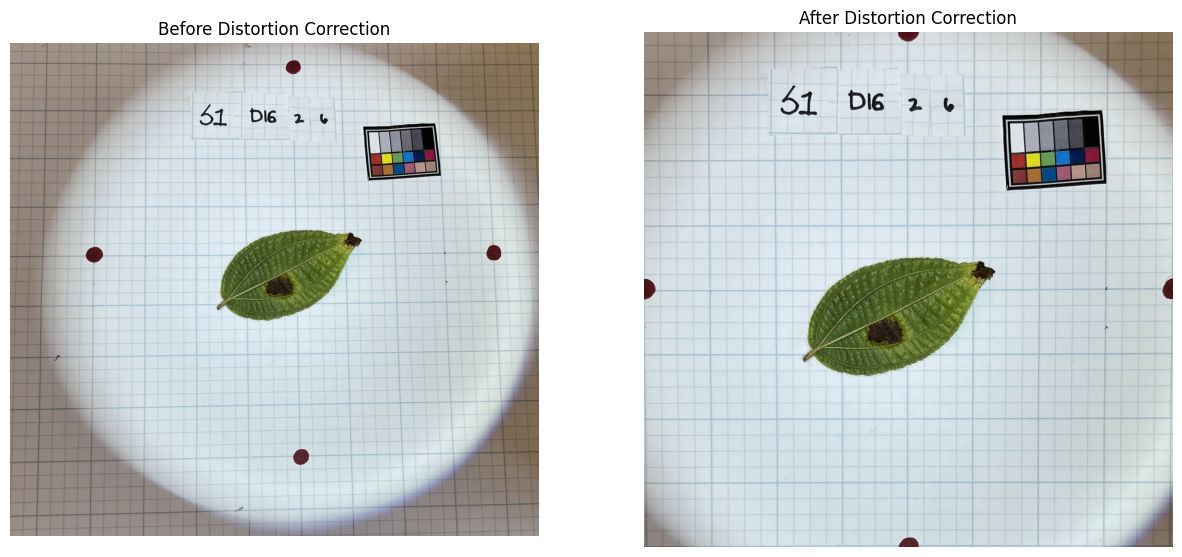

In [40]:
plt.figure(figsize=(15,15))
plt.subplot(121)
plt.axis("off")
plt.imshow(im.astype(np.uint8))
plt.title("Before Distortion Correction")
plt.subplot(122)
plt.axis("off")
plt.imshow(transformed_image.astype(np.uint8))
plt.title("After Distortion Correction")
plt.show()